In [94]:
import os
import optuna
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import xgboost as xgb
from scipy import optimize
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt
from sklearn import ensemble, metrics, neighbors

In [95]:
def caluculate_eer(y_true, y_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score, pos_label=1)

    eer = optimize.brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    thresh = interp1d(fpr, thresholds)(eer)

    return eer, thresh

In [96]:
training_df = pd.read_csv('data2/for-original_train.csv').dropna(axis=0)
testing_df = pd.read_csv('data2/for-original_test.csv').dropna(axis=0)
validation_df = pd.read_csv('data2/for-original_validation.csv').dropna(axis=0)

X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1).dropna(axis=0)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1).dropna(axis=0)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1).dropna(axis=0)

X_train_valid = pd.concat([X_train, X_valid], ignore_index=False)

y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']

y_train_valid = pd.concat([y_train, y_valid], ignore_index=False)

In [97]:
norm_training_df = pd.read_csv('data2/for-norm_train.csv').dropna(axis=0)
norm_testing_df = pd.read_csv('data2/for-norm_test.csv').dropna(axis=0)
norm_validation_df = pd.read_csv('data2/for-norm_validation.csv').dropna(axis=0)

X_norm_training = norm_training_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_testing = norm_testing_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_validation = norm_validation_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_norm_train_valid = pd.concat([X_norm_training, X_norm_validation], ignore_index=False)


y_norm_training = norm_training_df['label']
y_norm_testing = norm_testing_df['label']
y_norm_validation = norm_validation_df['label']

y_norm_train_valid = pd.concat([y_norm_training, y_norm_validation], ignore_index=False)


In [98]:
sec_train = pd.read_csv('data2/for-2sec_train.csv').dropna(axis=0)
sec_test = pd.read_csv('data2/for-2sec_test.csv').dropna(axis=0)
sec_valid = pd.read_csv('data2/for-2sec_validation.csv').dropna(axis=0)

X_sec_train = sec_train.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_test = sec_test.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_valid = sec_valid.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_sec_train_valid = pd.concat([X_sec_train, X_sec_valid], ignore_index=False)

y_sec_train = sec_train['label']
y_sec_test = sec_test['label']
y_sec_valid = sec_valid['label']

y_sec_train_valid = pd.concat([y_sec_train, y_sec_valid], ignore_index=False)

In [99]:
rerec_train_df = pd.read_csv('data2/for-rerec_train.csv').dropna(axis=0)
rerec_test_df = pd.read_csv('data2/for-rerec_test.csv').dropna(axis=0)
rerec_valid_df = pd.read_csv('data2/for-rerec_validation.csv').dropna(axis=0)

X_rerec_train = rerec_train_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_test = rerec_test_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_valid = rerec_valid_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)

X_rerec_train_valid = pd.concat([X_rerec_train, X_rerec_valid], ignore_index=False)

y_rerec_train = rerec_train_df['label']
y_rerec_test = rerec_test_df['label']
y_rerec_valid = rerec_valid_df['label']

y_rerec_train_valid = pd.concat([y_rerec_train, y_rerec_valid], ignore_index=False)

In [100]:
datasets = {
    "original":(X_train, X_valid, y_train, y_valid),
    "norm":(X_norm_training, X_norm_validation,  y_norm_training, y_norm_validation),
    "sec":(X_sec_train, X_sec_valid, y_sec_train, y_sec_valid),
    "rerec":(X_rerec_train, X_rerec_valid,  y_rerec_train, y_rerec_valid),
}

In [76]:
# Оптимизация гиперпараметров RF-моделей со всеми признаками
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 5, 100)
        max_depth = trial.suggest_int('max_depth', 1, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        clf = ensemble.RandomForestClassifier(
            n_estimators=n_estimators,
            criterion='entropy',
            max_depth=max_depth,
            max_features='sqrt',
            min_samples_leaf=min_samples_leaf
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))


        # y_pred_test = clf.predict(X_test)
        
        # score = metrics.accuracy_score(y_test, y_pred_test)

        return eer
    return objective



In [77]:
db_url = "sqlite:///RF_full2.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"rf_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-03-22 13:24:58,198] A new study created in RDB with name: rf_original
[I 2026-03-22 13:25:06,392] Trial 0 finished with value: 0.0003705075958385099 and parameters: {'n_estimators': 16, 'max_depth': 11, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.0003705075958385099.
[I 2026-03-22 13:25:26,259] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 37, 'max_depth': 15, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.0.
[I 2026-03-22 13:25:36,648] Trial 2 finished with value: 0.0003705075951100616 and parameters: {'n_estimators': 23, 'max_depth': 7, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.0.
[I 2026-03-22 13:25:56,716] Trial 3 finished with value: 0.0 and parameters: {'n_estimators': 38, 'max_depth': 15, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.0.
[I 2026-03-22 13:26:45,163] Trial 4 finished with value: 0.00018525379770161887 and parameters: {'n_estimators': 93, 'max_depth': 20, 'min_samples_leaf': 3}. Best is trial 1 with va

Лучшие параметры для original: {'n_estimators': 37, 'max_depth': 15, 'min_samples_leaf': 2} с показателем EER: 0.0

>>> Запуск оптимизации для датасета: norm


[I 2026-03-22 14:02:30,266] A new study created in RDB with name: rf_norm
[I 2026-03-22 14:02:44,144] Trial 0 finished with value: 0.009907997169129894 and parameters: {'n_estimators': 97, 'max_depth': 12, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.009907997169129894.
[I 2026-03-22 14:02:49,230] Trial 1 finished with value: 0.08138711960400238 and parameters: {'n_estimators': 71, 'max_depth': 4, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.009907997169129894.
[I 2026-03-22 14:02:55,941] Trial 2 finished with value: 0.012738853503467358 and parameters: {'n_estimators': 46, 'max_depth': 11, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.009907997169129894.
[I 2026-03-22 14:03:07,905] Trial 3 finished with value: 0.009907997169698202 and parameters: {'n_estimators': 86, 'max_depth': 11, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.009907997169129894.
[I 2026-03-22 14:03:09,776] Trial 4 finished with value: 0.016985138004246284 and parameters: {'n_estima

Лучшие параметры для norm: {'n_estimators': 93, 'max_depth': 20, 'min_samples_leaf': 1} с показателем EER: 0.006841236140643075

>>> Запуск оптимизации для датасета: sec


[I 2026-03-22 14:24:42,198] A new study created in RDB with name: rf_sec
[I 2026-03-22 14:24:52,561] Trial 0 finished with value: 0.012031139419764863 and parameters: {'n_estimators': 57, 'max_depth': 17, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.012031139419764863.
[I 2026-03-22 14:25:04,623] Trial 1 finished with value: 0.010615711253418791 and parameters: {'n_estimators': 68, 'max_depth': 19, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.010615711253418791.
[I 2026-03-22 14:25:14,213] Trial 2 finished with value: 0.05095541401273889 and parameters: {'n_estimators': 92, 'max_depth': 5, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.010615711253418791.
[I 2026-03-22 14:25:22,593] Trial 3 finished with value: 0.08209483368719035 and parameters: {'n_estimators': 95, 'max_depth': 4, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.010615711253418791.
[I 2026-03-22 14:25:28,909] Trial 4 finished with value: 0.011323425336860761 and parameters: {'n_estimato

Лучшие параметры для sec: {'n_estimators': 69, 'max_depth': 14, 'min_samples_leaf': 3} с показателем EER: 0.0063694267516641615

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-22 14:45:19,897] A new study created in RDB with name: rf_rerec
[I 2026-03-22 14:45:21,727] Trial 0 finished with value: 0.2297910990006157 and parameters: {'n_estimators': 98, 'max_depth': 1, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.2297910990006157.
[I 2026-03-22 14:45:23,395] Trial 1 finished with value: 0.07720254314347849 and parameters: {'n_estimators': 15, 'max_depth': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.07720254314347849.
[I 2026-03-22 14:45:23,910] Trial 2 finished with value: 0.20435967302537766 and parameters: {'n_estimators': 15, 'max_depth': 2, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.07720254314347849.
[I 2026-03-22 14:45:29,987] Trial 3 finished with value: 0.09627611262530028 and parameters: {'n_estimators': 74, 'max_depth': 6, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.07720254314347849.
[I 2026-03-22 14:45:40,473] Trial 4 finished with value: 0.05449591280782424 and parameters: {'n_estimators': 92, '

Лучшие параметры для rerec: {'n_estimators': 86, 'max_depth': 19, 'min_samples_leaf': 1} с показателем EER: 0.03471103954195739


In [78]:
# Оптимизация гиперпараметров XGB-моделей
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'gamma': trial.suggest_float('gamma', 1e-8, 0.5, log=True),
            'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
            'subsample':trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42
        }

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))

        return eer
    
    return objective

In [79]:
db_url = "sqlite:///XGB_research2.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"xgb_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-03-22 14:59:45,807] A new study created in RDB with name: xgb_original
c:\Users\Kirill\miniconda3\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
[I 2026-03-22 14:59:47,576] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 127, 'learning_rate': 0.379941820607834, 'max_depth': 10, 'gamma': 0.00025880465619059216, 'lambda': 0.019019209213634838, 'alpha': 1.3429386021732643e-08, 'subsample': 0.8597367534931513, 'colsample_bytree': 0.6002508635564647}. Best is trial 0 with value: 0.0.
c:\Users\Kirill\miniconda3\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
[I 2026-03-22 14:59:51,670] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 361, 'learning_rate': 0.0272622929271662, 'max_depth': 5, 'gamma': 0.010115352766696077, 'lambda': 1

Лучшие параметры для original: {'n_estimators': 127, 'learning_rate': 0.379941820607834, 'max_depth': 10, 'gamma': 0.00025880465619059216, 'lambda': 0.019019209213634838, 'alpha': 1.3429386021732643e-08, 'subsample': 0.8597367534931513, 'colsample_bytree': 0.6002508635564647} с показателем EER: 0.0

>>> Запуск оптимизации для датасета: norm


[I 2026-03-22 15:07:08,720] A new study created in RDB with name: xgb_norm
[I 2026-03-22 15:07:12,404] Trial 0 finished with value: 0.002123142251571648 and parameters: {'n_estimators': 533, 'learning_rate': 0.05563695758181053, 'max_depth': 6, 'gamma': 0.41600014828696136, 'lambda': 1.6528968338828763e-06, 'alpha': 0.0005165328000946617, 'subsample': 0.8858334703801662, 'colsample_bytree': 0.7254290549349899}. Best is trial 0 with value: 0.002123142251571648.
[I 2026-03-22 15:07:13,565] Trial 1 finished with value: 0.005661712668800702 and parameters: {'n_estimators': 282, 'learning_rate': 0.7297247473239973, 'max_depth': 3, 'gamma': 1.5284310334259082e-05, 'lambda': 0.18880722839118433, 'alpha': 1.8032613239476535e-08, 'subsample': 0.7747326962594167, 'colsample_bytree': 0.7675796103412551}. Best is trial 0 with value: 0.002123142251571648.
[I 2026-03-22 15:07:24,250] Trial 2 finished with value: 0.002123142251745811 and parameters: {'n_estimators': 751, 'learning_rate': 0.0273257194

Лучшие параметры для norm: {'n_estimators': 440, 'learning_rate': 0.13090447674008207, 'max_depth': 6, 'gamma': 6.168603529734507e-06, 'lambda': 0.00011397693281519425, 'alpha': 0.6915257510697884, 'subsample': 0.6709559960501832, 'colsample_bytree': 0.6036239251789448} с показателем EER: 0.0021231422505307903

>>> Запуск оптимизации для датасета: sec


[I 2026-03-22 15:13:53,045] A new study created in RDB with name: xgb_sec
[I 2026-03-22 15:13:55,352] Trial 0 finished with value: 0.003538570416442602 and parameters: {'n_estimators': 413, 'learning_rate': 0.08123685361917501, 'max_depth': 4, 'gamma': 0.00018711725736634974, 'lambda': 1.3262325555158016e-07, 'alpha': 1.5585376493145036e-06, 'subsample': 0.6288804966687741, 'colsample_bytree': 0.7998763993046817}. Best is trial 0 with value: 0.003538570416442602.
[I 2026-03-22 15:13:58,365] Trial 1 finished with value: 0.0028308563340810494 and parameters: {'n_estimators': 520, 'learning_rate': 0.24252614153907223, 'max_depth': 10, 'gamma': 0.017687028634842523, 'lambda': 0.00012718522720554337, 'alpha': 6.497785002601445e-05, 'subsample': 0.7461701767218258, 'colsample_bytree': 0.6226074056387058}. Best is trial 1 with value: 0.0028308563340810494.
[I 2026-03-22 15:14:02,122] Trial 2 finished with value: 0.002123142250530993 and parameters: {'n_estimators': 474, 'learning_rate': 0.081

Лучшие параметры для sec: {'n_estimators': 505, 'learning_rate': 0.07167893172303066, 'max_depth': 7, 'gamma': 2.387462282910548e-05, 'lambda': 5.593613923582884e-07, 'alpha': 1.325080900597021e-08, 'subsample': 0.7270310405143567, 'colsample_bytree': 0.8159833477159066} с показателем EER: 0.0021231422499869614

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-22 15:20:13,065] A new study created in RDB with name: xgb_rerec
[I 2026-03-22 15:20:15,923] Trial 0 finished with value: 0.016348773841770352 and parameters: {'n_estimators': 620, 'learning_rate': 0.18575650577160804, 'max_depth': 6, 'gamma': 0.0011801475466013576, 'lambda': 0.00036798341861746155, 'alpha': 0.009948583582752971, 'subsample': 0.6221931721019028, 'colsample_bytree': 0.8512484877797586}. Best is trial 0 with value: 0.016348773841770352.
[I 2026-03-22 15:20:18,304] Trial 1 finished with value: 0.013998250219140057 and parameters: {'n_estimators': 511, 'learning_rate': 0.19483815675586347, 'max_depth': 6, 'gamma': 1.15855447674092e-08, 'lambda': 1.2619509493612722e-05, 'alpha': 0.006803649440641469, 'subsample': 0.8536822549367193, 'colsample_bytree': 0.62441668736714}. Best is trial 1 with value: 0.013998250219140057.
[I 2026-03-22 15:20:20,699] Trial 2 finished with value: 0.020997375328083965 and parameters: {'n_estimators': 700, 'learning_rate': 0.0421565070

Лучшие параметры для rerec: {'n_estimators': 640, 'learning_rate': 0.09729615749786033, 'max_depth': 5, 'gamma': 2.820745620878044e-05, 'lambda': 0.000523970770751886, 'alpha': 0.03839774319694617, 'subsample': 0.7888778690353295, 'colsample_bytree': 0.6001645134845561} с показателем EER: 0.013123359580338464


In [92]:
# Оптимизация гиперпараметров KNN-моделей
def create_objective(X_tr, X_test, y_tr, y_test):

    def objective(trial):
        
        n_neighbors = trial.suggest_int('n_neighbors', 2, 60)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        leaf_size = trial.suggest_int('leaf_size', 10, 50)
        p = trial.suggest_int('p', 1, 2)

        clf = neighbors.KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            leaf_size=leaf_size,
            p=p,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_test)[:, 1]

        eer, best_threshold = caluculate_eer(y_test, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_test, y_score > 0.5))

        return eer
    
    return objective

In [93]:
db_url = "sqlite:///knn_research2.db"
for name, (X_tr, X_test, y_tr, y_test) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"knn_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_test, y_tr, y_test)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-03-22 21:38:02,023] A new study created in RDB with name: knn_original
[I 2026-03-22 21:38:03,196] Trial 0 finished with value: 0.06255855287926945 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'leaf_size': 34, 'p': 2}. Best is trial 0 with value: 0.06255855287926945.
[I 2026-03-22 21:38:04,430] Trial 1 finished with value: 0.07753683489126642 and parameters: {'n_neighbors': 57, 'weights': 'uniform', 'leaf_size': 14, 'p': 2}. Best is trial 0 with value: 0.06255855287926945.
[I 2026-03-22 21:38:05,574] Trial 2 finished with value: 0.0535383475361231 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'leaf_size': 27, 'p': 2}. Best is trial 2 with value: 0.0535383475361231.
[I 2026-03-22 21:38:16,415] Trial 3 finished with value: 0.022867096582907934 and parameters: {'n_neighbors': 38, 'weights': 'uniform', 'leaf_size': 11, 'p': 1}. Best is trial 3 with value: 0.022867096582907934.
[I 2026-03-22 21:38:17,595] Trial 4 finished with value: 0.06488691138311653 and

Лучшие параметры для original: {'n_neighbors': 4, 'weights': 'distance', 'leaf_size': 43, 'p': 1} с показателем EER: 0.011679644050341682

>>> Запуск оптимизации для датасета: norm


[I 2026-03-22 21:54:16,638] Trial 0 finished with value: 0.23385223622436327 and parameters: {'n_neighbors': 39, 'weights': 'uniform', 'leaf_size': 46, 'p': 2}. Best is trial 0 with value: 0.23385223622436327.
[I 2026-03-22 21:54:16,847] Trial 1 finished with value: 0.23000707714132823 and parameters: {'n_neighbors': 46, 'weights': 'distance', 'leaf_size': 49, 'p': 2}. Best is trial 1 with value: 0.23000707714132823.
[I 2026-03-22 21:54:17,638] Trial 2 finished with value: 0.09135214049551288 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'leaf_size': 14, 'p': 1}. Best is trial 2 with value: 0.09135214049551288.
[I 2026-03-22 21:54:18,434] Trial 3 finished with value: 0.09235761298504395 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'leaf_size': 11, 'p': 1}. Best is trial 2 with value: 0.09135214049551288.
[I 2026-03-22 21:54:19,253] Trial 4 finished with value: 0.1286040822873641 and parameters: {'n_neighbors': 53, 'weights': 'uniform', 'leaf_size': 25, 'p': 1}.

Лучшие параметры для norm: {'n_neighbors': 6, 'weights': 'distance', 'leaf_size': 19, 'p': 1} с показателем EER: 0.07218683651803408

>>> Запуск оптимизации для датасета: sec


[I 2026-03-22 21:55:30,367] A new study created in RDB with name: knn_sec
[I 2026-03-22 21:55:30,603] Trial 0 finished with value: 0.23915990937797957 and parameters: {'n_neighbors': 46, 'weights': 'uniform', 'leaf_size': 47, 'p': 2}. Best is trial 0 with value: 0.23915990937797957.
[I 2026-03-22 21:55:30,805] Trial 1 finished with value: 0.21585279547063088 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'leaf_size': 44, 'p': 2}. Best is trial 1 with value: 0.21585279547063088.
[I 2026-03-22 21:55:30,985] Trial 2 finished with value: 0.2002830856334041 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'leaf_size': 17, 'p': 2}. Best is trial 2 with value: 0.2002830856334041.
[I 2026-03-22 21:55:31,812] Trial 3 finished with value: 0.12987889214991735 and parameters: {'n_neighbors': 55, 'weights': 'uniform', 'leaf_size': 14, 'p': 1}. Best is trial 3 with value: 0.12987889214991735.
[I 2026-03-22 21:55:32,621] Trial 4 finished with value: 0.10006847536067626 and parame

Лучшие параметры для sec: {'n_neighbors': 6, 'weights': 'distance', 'leaf_size': 27, 'p': 1} с показателем EER: 0.07218683651803408

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-22 21:56:44,496] A new study created in RDB with name: knn_rerec
[I 2026-03-22 21:56:44,991] Trial 0 finished with value: 0.15748031496061562 and parameters: {'n_neighbors': 21, 'weights': 'distance', 'leaf_size': 32, 'p': 1}. Best is trial 0 with value: 0.15748031496061562.
[I 2026-03-22 21:56:45,151] Trial 1 finished with value: 0.28952076237657826 and parameters: {'n_neighbors': 57, 'weights': 'uniform', 'leaf_size': 11, 'p': 2}. Best is trial 0 with value: 0.15748031496061562.
[I 2026-03-22 21:56:45,660] Trial 2 finished with value: 0.20332439859067078 and parameters: {'n_neighbors': 47, 'weights': 'uniform', 'leaf_size': 44, 'p': 1}. Best is trial 0 with value: 0.15748031496061562.
[I 2026-03-22 21:56:45,806] Trial 3 finished with value: 0.2747156605425737 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'leaf_size': 41, 'p': 2}. Best is trial 0 with value: 0.15748031496061562.
[I 2026-03-22 21:56:45,978] Trial 4 finished with value: 0.2824704813800934 and para

Лучшие параметры для rerec: {'n_neighbors': 7, 'weights': 'distance', 'leaf_size': 47, 'p': 1} с показателем EER: 0.14435695538057694


# Final test

In [102]:
datasets = {
    'original': {'train': (X_train_valid, y_train_valid) , 'test': (X_test, y_test)},
    'norm': {'train': (X_norm_train_valid, y_norm_train_valid), 'test': (X_norm_testing, y_norm_testing)},
    '2sec': {'train': (X_sec_train_valid, y_sec_train_valid), 'test': (X_sec_test, y_sec_test) },
    'rerec': {'train': (X_rerec_train_valid, y_rerec_train_valid), 'test': (X_rerec_test, y_rerec_test)}
}

## RF

In [107]:
rf_best_params = {
    'original': {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 8 } ,
    'norm': {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 7 },
    '2sec': {'max_depth': 1, 'min_samples_leaf': 2, 'n_estimators': 8 },
    'rerec': {'max_depth': 1, 'min_samples_leaf': 5, 'n_estimators': 9 },
}

c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\s

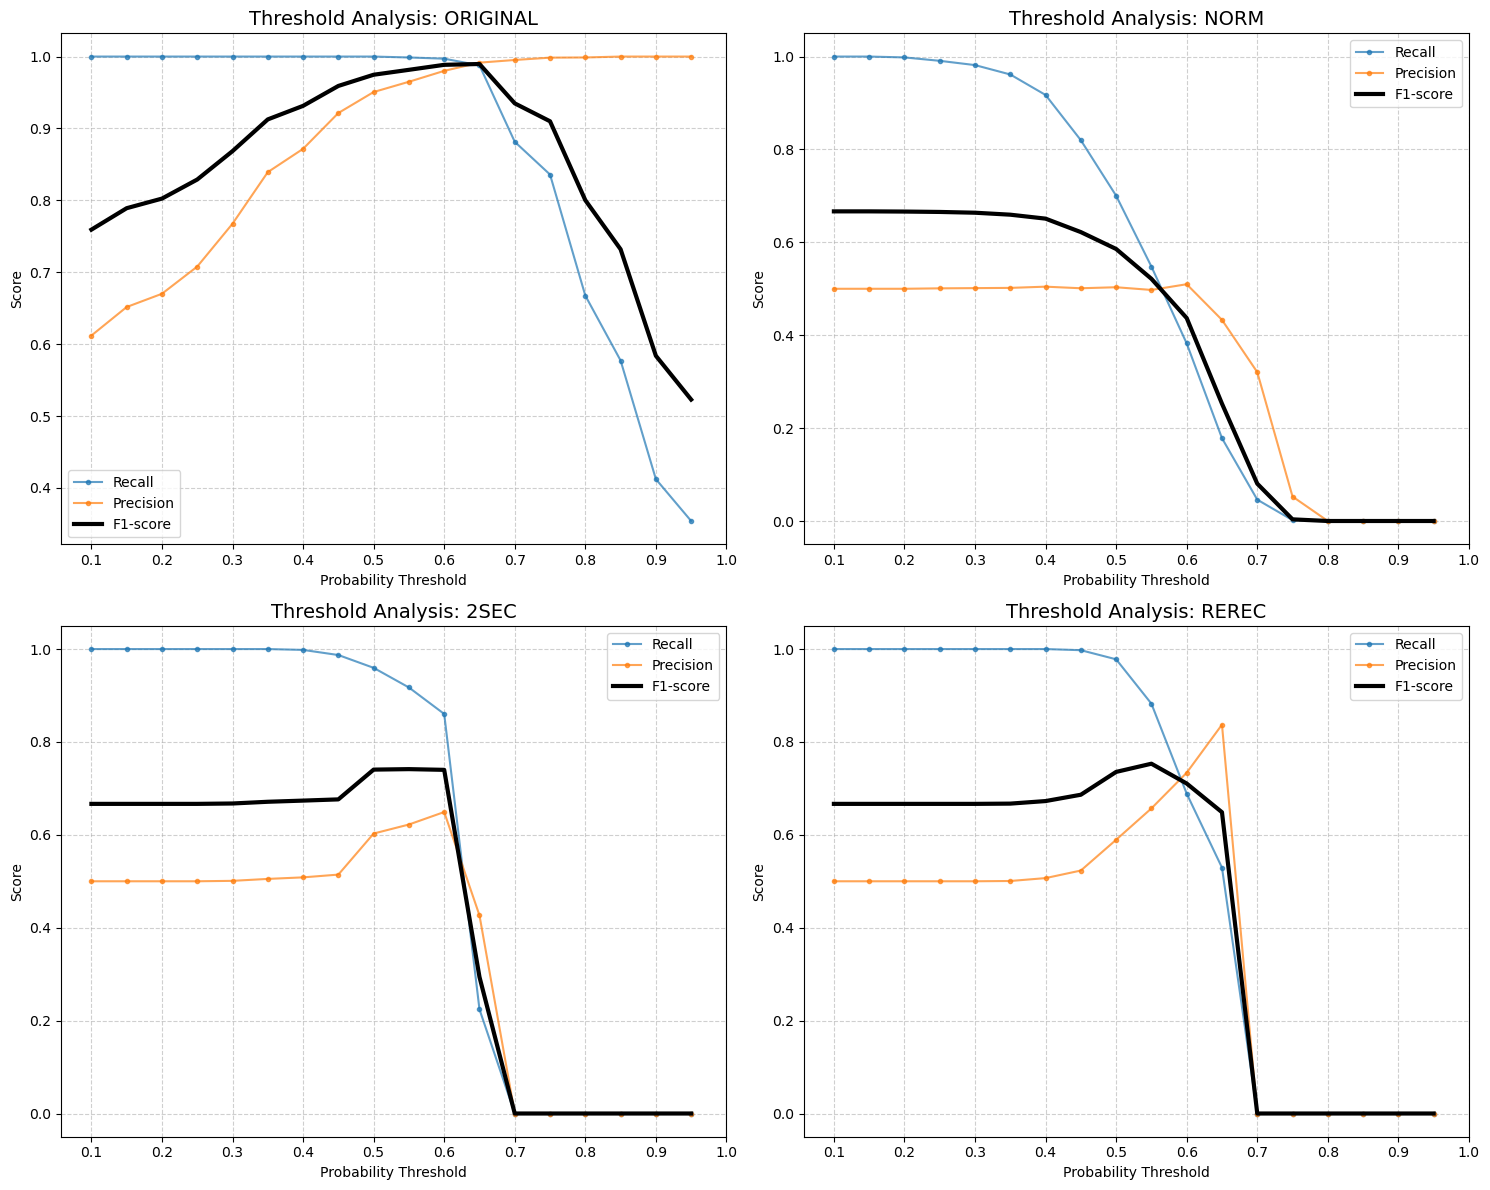

In [108]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = rf_best_params[name]
    
    # Инициализация и обучение модели
    model = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()
    
    

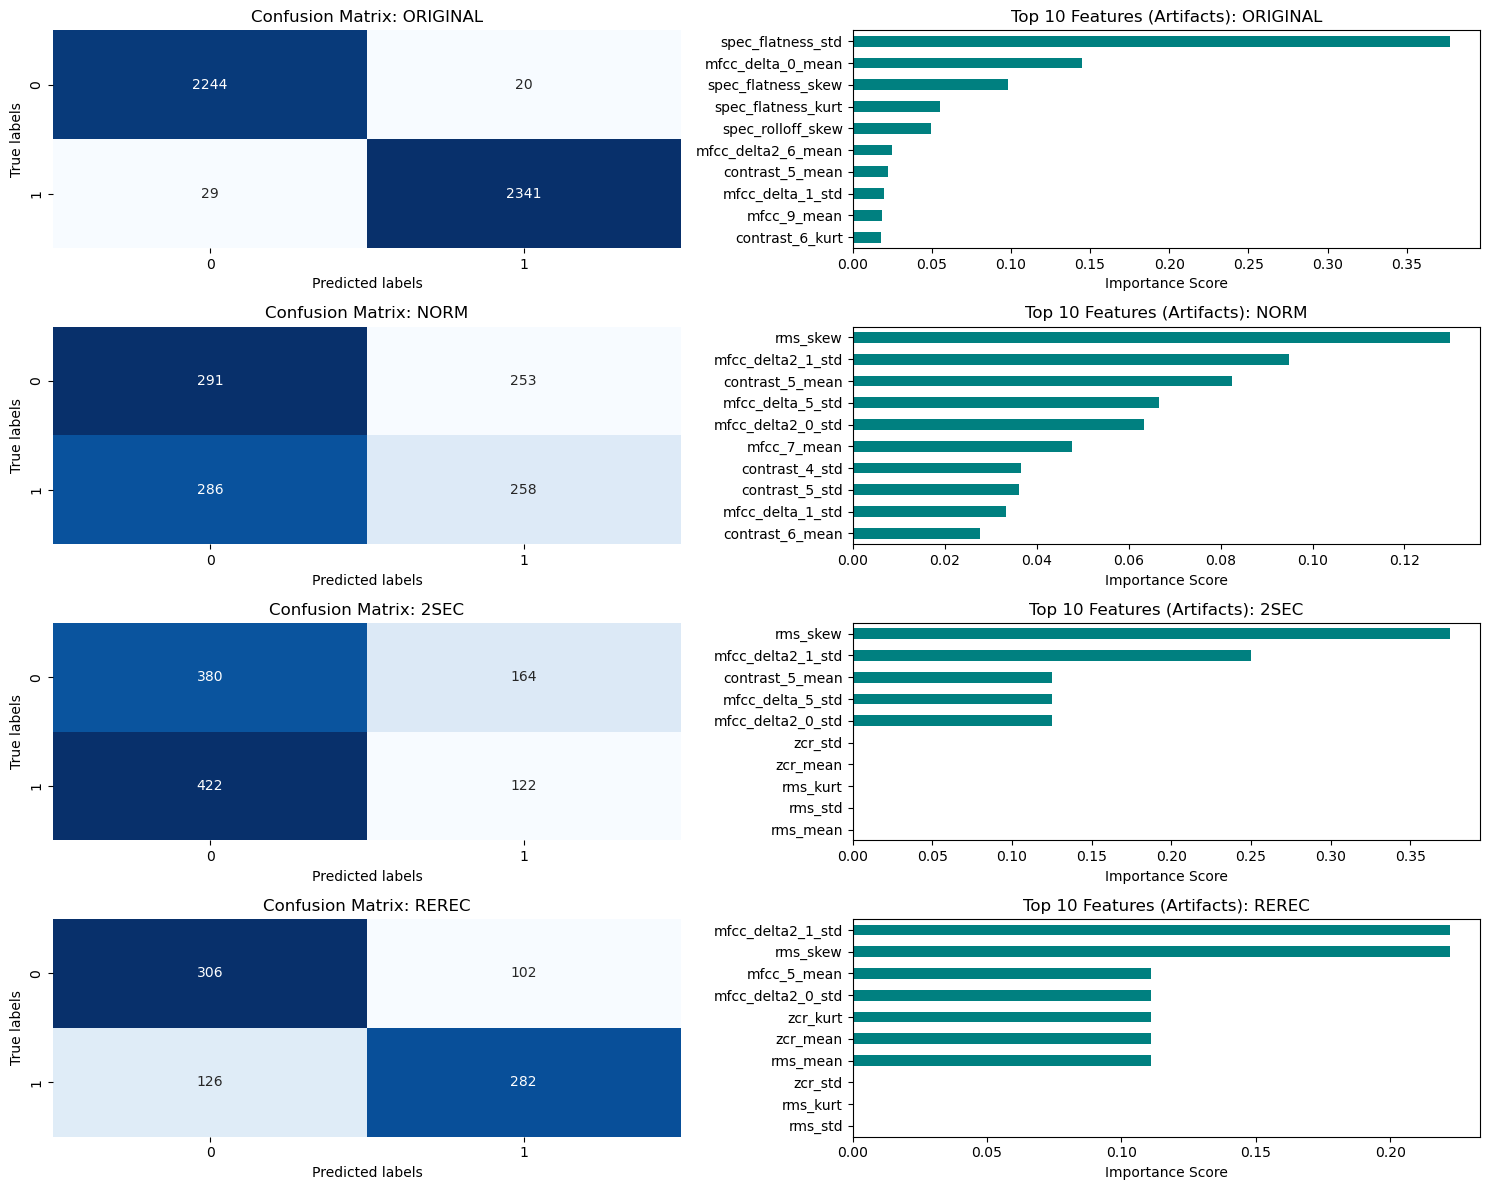


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.011484  0.989426  0.989643   0.991529  0.987764
1      norm  0.494485  0.504596  0.489100   0.504892  0.474265
2      2sec  0.356904  0.461397  0.293976   0.426573  0.224265
3     rerec  0.263932  0.720588  0.712121   0.734375  0.691176


In [127]:
final_metrics = []

custom_thresholds = {
      'original': 0.65,
      'norm': 0.57,
      '2sec': 0.62,
      'rerec': 0.59, 
}

fig, axes = plt.subplots(4,2, figsize=(15,12))
#axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = rf_best_params[name]
    
    # Инициализация и обучение модели
    model = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i, 0], cmap='Blues', cbar=False)
    axes[i, 0].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i, 0].set_xlabel('Predicted labels')
    axes[i, 0].set_ylabel('True labels')

    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f"Top 10 Features (Artifacts): {name.upper()}", fontsize=12)
    axes[i, 1].set_xlabel('Importance Score')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research2_rf_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)

## XGB

In [113]:
xgb_best_params = {
    'original': {
        'n_estimators':  438,
        'learning_rate': 0.29750779056997045,
        'max_depth': 1,
        'gamma': 1.5350841159282887e-8,
        'lambda': 0.000004950222139374845,
        'alpha': 0.0062506616441690204	,
        'subsample': 0.8658215161115285	,
        'colsample_bytree': 0.7570811841145092,
        'random_state': 42
    },
    'norm': {
        'n_estimators':  717,
        'learning_rate': 0.11193430516864646,
        'max_depth': 1,
        'gamma': 0.0008984420674291169,
        'lambda': 0.007180915225687801,
        'alpha': 1.0059601049143309e-8,
        'subsample': 0.6003237704029185	,
        'colsample_bytree': 0.8820125707984218,
        'random_state': 42
    },
    '2sec': {
        'n_estimators':  575,
        'learning_rate': 0.2638429594659329,
        'max_depth': 1,
        'gamma': 0.015551154742862254,
        'lambda': 0.00000411400869957807,
        'alpha': 0.0005653955763417406	,
        'subsample': 0.8218839974726077	,
        'colsample_bytree':0.7487702068007135	,
        'random_state': 42
    },
    'rerec': {
        'n_estimators':  760,
        'learning_rate': 0.5851675563959351,
        'max_depth': 1,
        'gamma': 0.00041773997029781083,
        'lambda': 1.4749949901823225e-7	,
        'alpha': 0.9462100575278592,
        'subsample': 0.8218839974726077	,
        'colsample_bytree':0.7902737228685935,
        'random_state': 42
    },
}

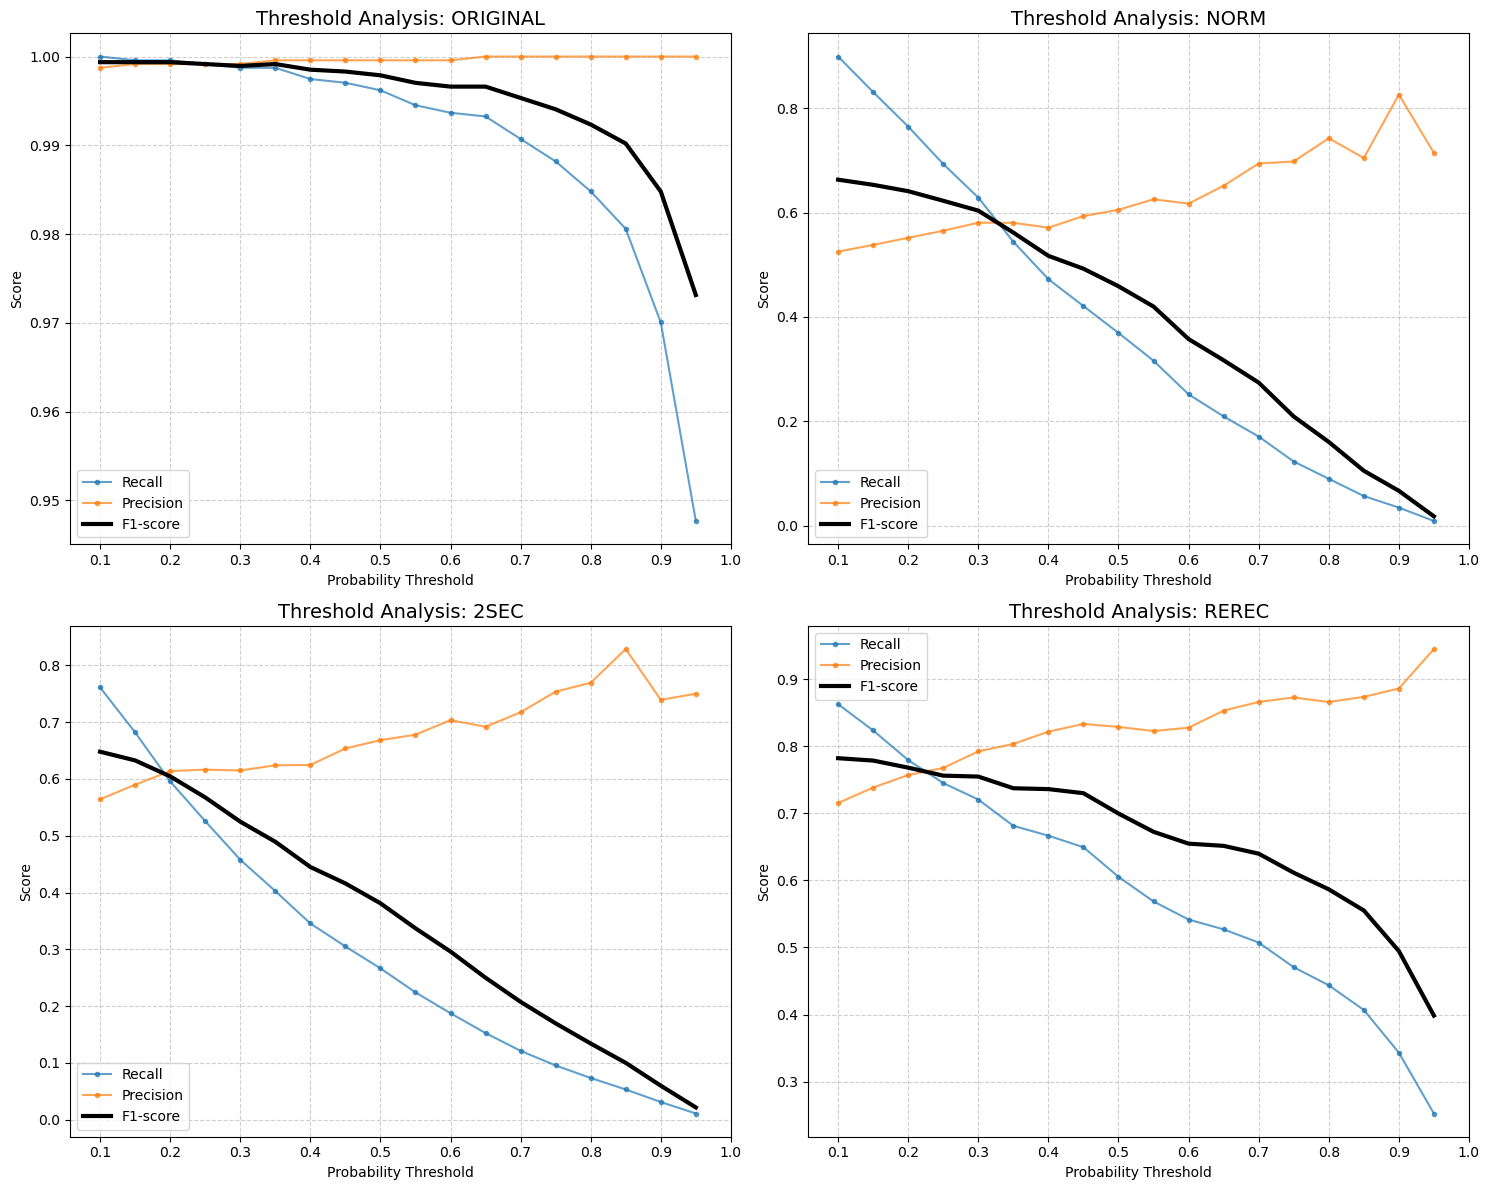

In [114]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = xgb_best_params[name]
    
    # Инициализация и обучение модели
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom, zero_division=0))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom, zero_division=0))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom, zero_division=0))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()

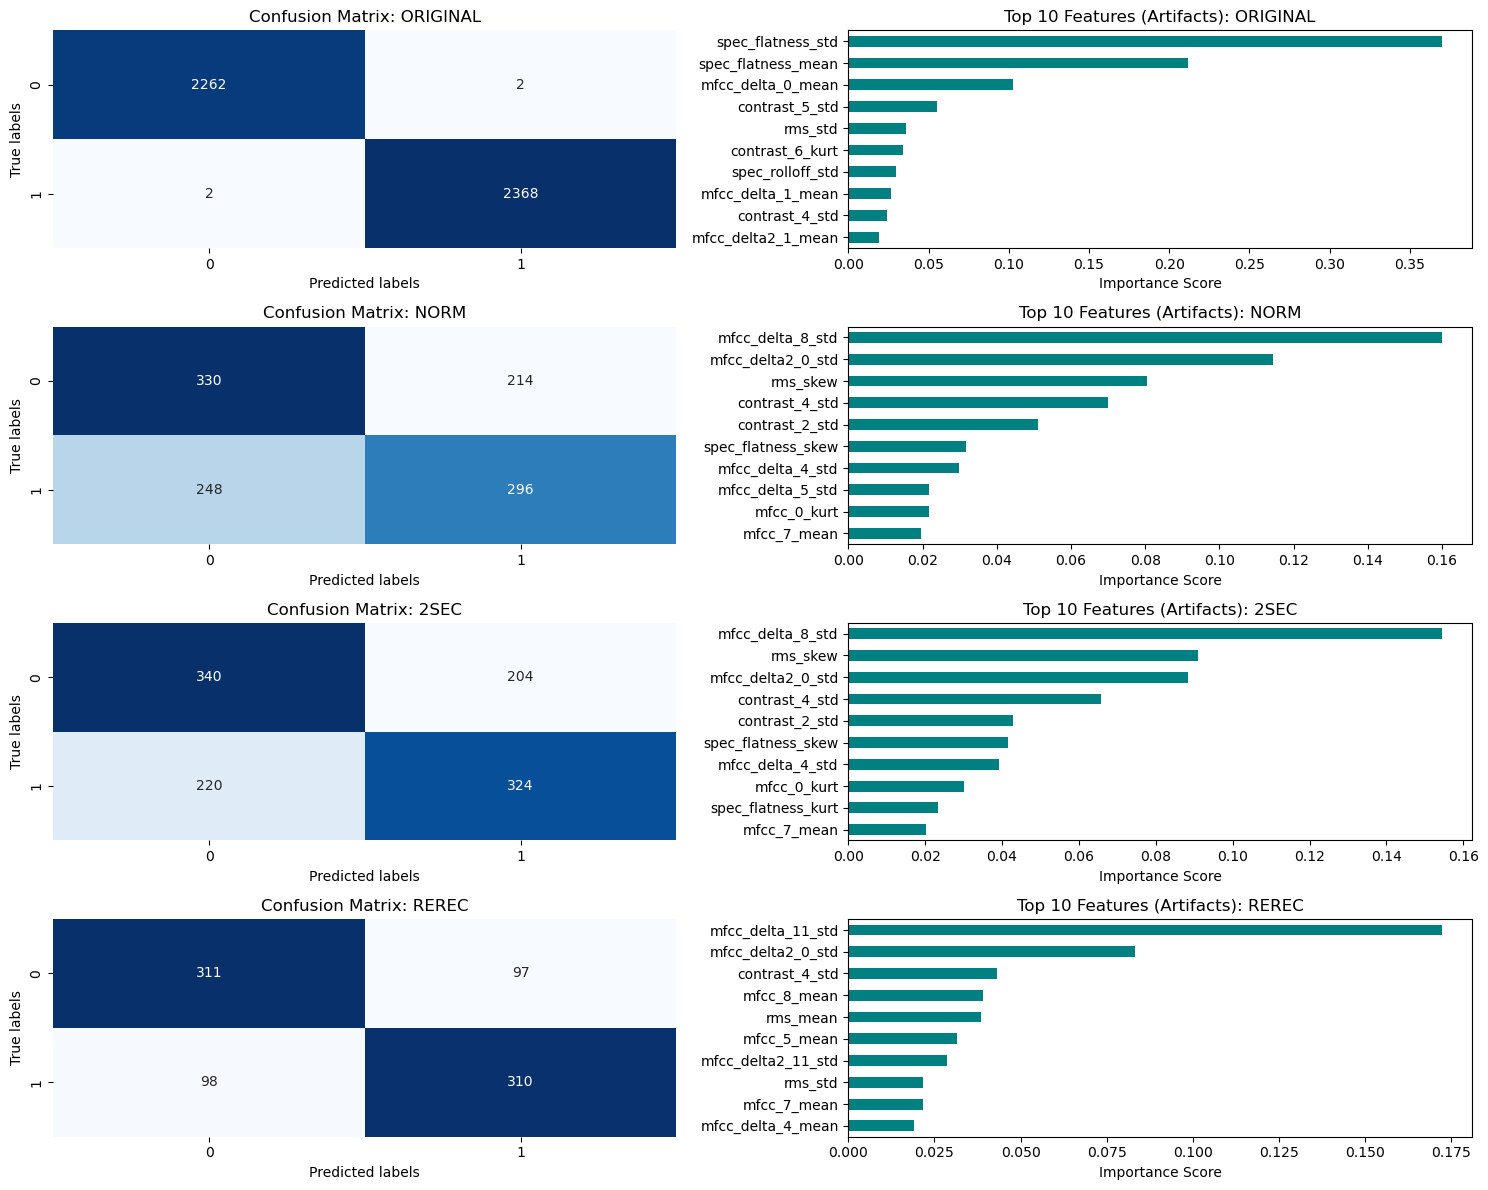


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.000883  0.999137  0.999156   0.999156  0.999156
1      norm  0.424632  0.575368  0.561670   0.580392  0.544118
2      2sec  0.387868  0.610294  0.604478   0.613636  0.595588
3     rerec  0.240196  0.761029  0.760736   0.761671  0.759804


In [128]:
final_metrics = []

custom_thresholds = {
      'original': 0.25,
      'norm': 0.35,
      '2sec': 0.2,
      'rerec': 0.23, 
}

fig, axes = plt.subplots(4,2, figsize=(15,12))
#axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = xgb_best_params[name]
    
    # Инициализация и обучение модели
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i, 0], cmap='Blues', cbar=False)
    axes[i, 0].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i, 0].set_xlabel('Predicted labels')
    axes[i, 0].set_ylabel('True labels')

    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f"Top 10 Features (Artifacts): {name.upper()}", fontsize=12)
    axes[i, 1].set_xlabel('Importance Score')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research2_xgb_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)

## KNN

In [117]:
knn_best_params = {
    'original': {
        'n_neighbors': 58,
        'weights': 'uniform',
        'leaf_size': 41,
        'p': 1,
    },
    'norm': {
        'n_neighbors': 58,
        'weights': 'distance',
        'leaf_size': 46,
        'p': 2,
    },
    '2sec': {
        'n_neighbors': 58,
        'weights': 'distance',
        'leaf_size': 45,
        'p': 2,
    },
    'rerec': {
        'n_neighbors': 41,
        'weights': 'distance',
        'leaf_size': 38,
        'p': 1,
    },
}

c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


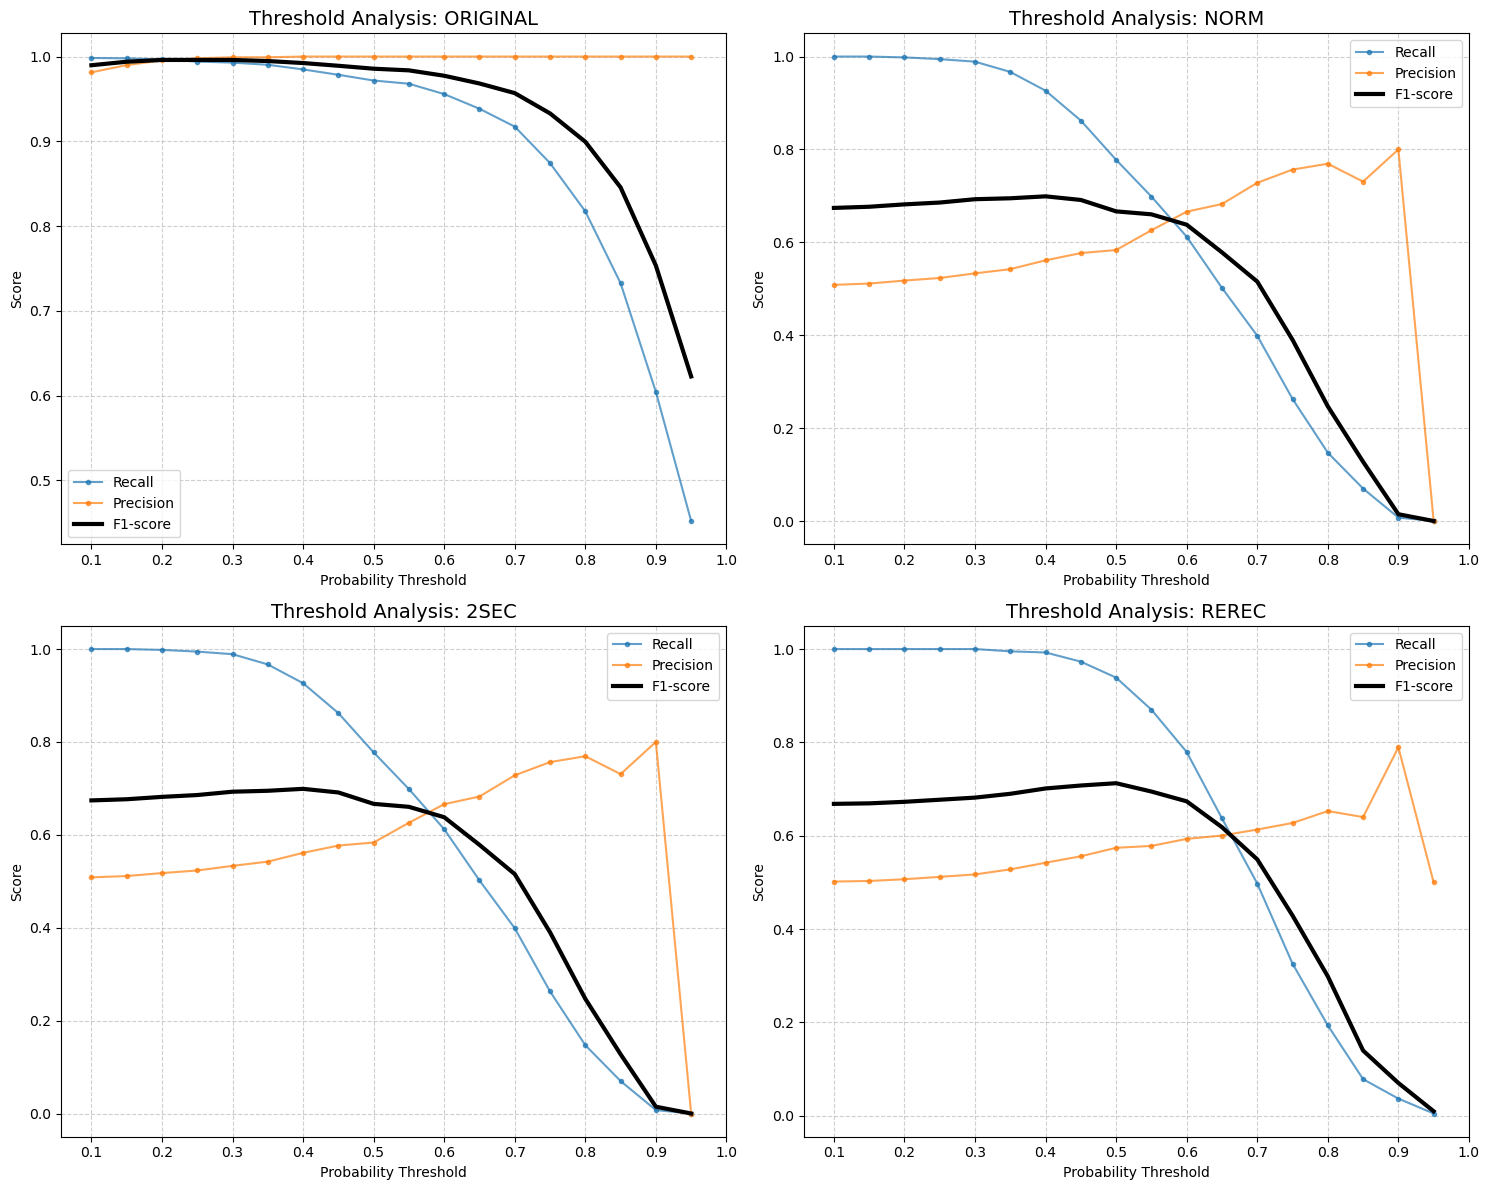

In [118]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = knn_best_params[name]
    
    # Инициализация и обучение модели
    model = neighbors.KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()

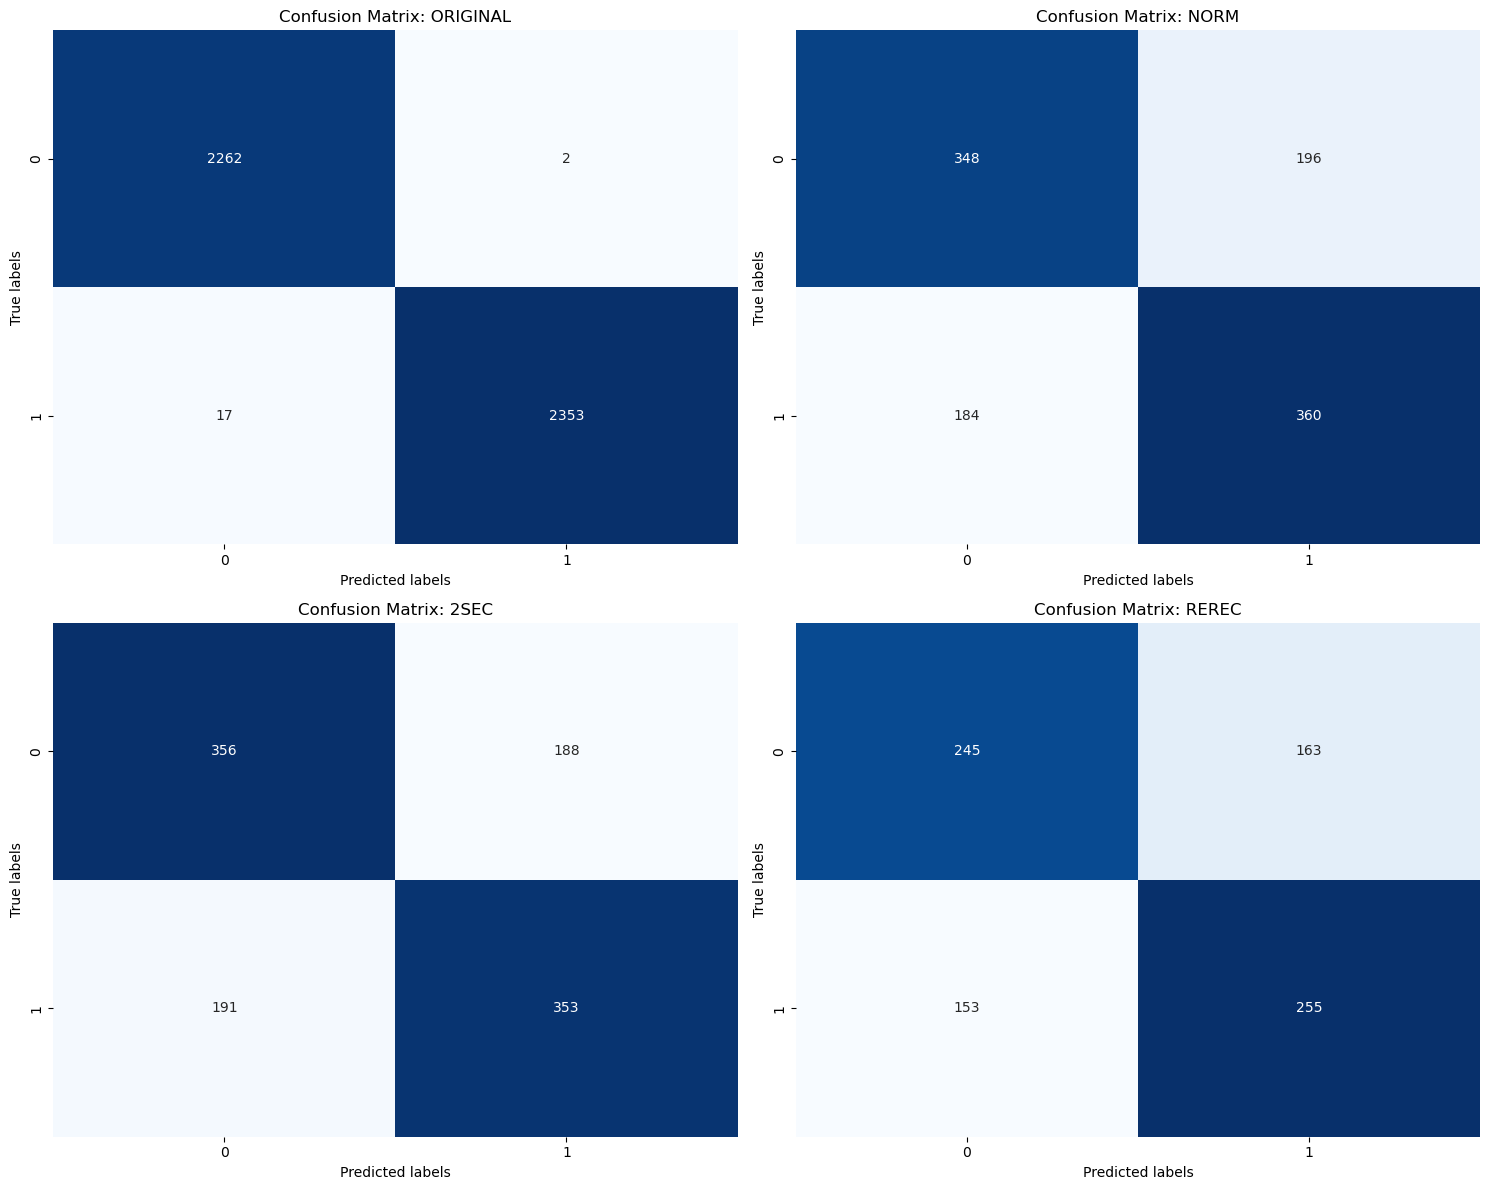

PermissionError: [Errno 13] Permission denied: 'results/research2_knn_result.xlsx'

In [129]:
final_metrics = []

custom_thresholds = {
      'original': 0.3,
      'norm': 0.575,
      '2sec': 0.585,
      'rerec': 0.66, 
}

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = knn_best_params[name]
    
    # Инициализация и обучение модели
    model = neighbors.KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i].set_xlabel('Predicted labels')
    axes[i].set_ylabel('True labels')

    

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research2_knn_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)